**1- Installing and importing packages**

In [ ]:

# Install required packages
!pip install torch-geometric torch-sparse torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install optuna
!pip install seaborn


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00a 0:00:01


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool  # Changed to GATv2Conv
from torch_geometric.data import Data, DataLoader
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch_geometric.typing
import warnings
import os
warnings.filterwarnings('ignore')


/usr/local/lib/python3.11/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/usr/local/lib/python3.11/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing


In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


**2- Preprocessing the datasets**

In [ ]:
# === DATA PREPROCESSING CHECK ===
import pandas as pd
import numpy as np

# Load all stock datasets
dataset_dir = '/kaggle/input/data-stock'
stock_files = {
    'NVDA': '/kaggle/input/data-stock/nvda_features.csv',
    'AAPL': '/kaggle/input/data-stock/aapl_features.csv',
    'AMZN': '/kaggle/input/data-stock/amzn_features.csv',
    'GOOGL': '/kaggle/input/data-stock/googl_features.csv',
    'META': '/kaggle/input/data-stock/meta_features.csv',
    'MSFT': '/kaggle/input/data-stock/msft_features.csv',
    'AMD': '/kaggle/input/data-stock/amd_features.csv',
    'INTC': '/kaggle/input/data-stock/intc_features.csv',
    # 'QCOM': '/kaggle/input/data-stock/qcom_features.csv',  # REMOVED: negative correlation
    'TSM': '/kaggle/input/data-stock/tsm_features.csv'
}

stock_data_dict = {}
print("Loading datasets...")

for stock, file_path in stock_files.items():
    print(f"📊Loading {stock}...")
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    stock_data_dict[stock] = df
    print(f"   ✅ {len(df)} rows, {len(df.columns)} columns")

print("\n" + "="*50)
print("DATA DIAGNOSTICS")
print("="*50)

# 1. Check NaN values
print("\n🔍 CHECKING NaN VALUES:")
for stock, df in stock_data_dict.items():
    nan_count = df.isna().sum().sum()
    if nan_count > 0:
        print(f"   ⚠️  {stock}: {nan_count} NaN values")
        nan_cols = df.columns[df.isna().any()].tolist()
        print(f"      NaN columns: {nan_cols}")
    else:
        print(f"   ✅ {stock}: No NaN values")

# 2. Check infinite values
print("\n🔍 CHECKING INFINITE VALUES:")
for stock, df in stock_data_dict.items():
    numeric_df = df.select_dtypes(include=[np.number])
    inf_count = np.isinf(numeric_df).sum().sum()
    if inf_count > 0:
        print(f"   ⚠️  {stock}: {inf_count} infinite values")
    else:
        print(f"   ✅ {stock}: No infinite values")

# 3. Check constant columns
print("\n🔍 CHECKING CONSTANT COLUMNS:")
for stock, df in stock_data_dict.items():
    numeric_df = df.select_dtypes(include=[np.number])
    constant_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() == 1]
    if constant_cols:
        print(f"   ⚠️  {stock}: {len(constant_cols)} constant columns")
        print(f"      Constant: {constant_cols}")
    else:
        print(f"   ✅ {stock}: No constant columns")

# 4. Check date alignment
print("\n🔍 CHECKING DATE ALIGNMENT:")
base_dates = stock_data_dict['NVDA']['Date']
for stock, df in stock_data_dict.items():
    if not base_dates.equals(df['Date']):
        print(f"   ⚠️  {stock}: Dates don't match NVDA")
        print(f"      NVDA: {base_dates.min()} to {base_dates.max()}")
        print(f"      {stock}: {df['Date'].min()} to {df['Date'].max()}")
    else:
        print(f"   ✅ {stock}: Dates match NVDA")

# 5. Check target variable
print("\n🔍 CHECKING TARGET VARIABLE (NVDA Adj_close):")
nvda_prices = stock_data_dict['NVDA']['Adj_close']
print(f"   Price range: ${nvda_prices.min():.2f} - ${nvda_prices.max():.2f}")
print(f"   Has zeros: {(nvda_prices == 0).any()}")
print(f"   Has negatives: {(nvda_prices < 0).any()}")
print(f"   Data points: {len(nvda_prices)}")

print("\n" + "="*50)
print("DIAGNOSTICS COMPLETE")
print("="*50)


Loading datasets...
📊Loading NVDA...
   ✅ 832 rows, 35 columns
📊Loading AAPL...
   ✅ 832 rows, 35 columns
📊Loading AMZN...
   ✅ 832 rows, 35 columns
📊Loading GOOGL...
   ✅ 832 rows, 35 columns
📊Loading META...
   ✅ 832 rows, 35 columns
📊Loading MSFT...
   ✅ 832 rows, 35 columns
📊Loading AMD...
   ✅ 832 rows, 35 columns
📊Loading INTC...
   ✅ 832 rows, 35 columns
📊Loading TSM...
   ✅ 832 rows, 35 columns

DATA DIAGNOSTICS

🔍 CHECKING NaN VALUES:
   ✅ NVDA: No NaN values
   ✅ AAPL: No NaN values
   ✅ AMZN: No NaN values
   ✅ GOOGL: No NaN values
   ✅ META: No NaN values
   ✅ MSFT: No NaN values
   ✅ AMD: No NaN values
   ✅ INTC: No NaN values
   ✅ TSM: No NaN values

🔍 CHECKING INFINITE VALUES:
   ✅ NVDA: No infinite values
   ✅ AAPL: No infinite values
   ✅ AMZN: No infinite values
   ✅ GOOGL: No infinite values
   ✅ META: No infinite values
   ✅ MSFT: No infinite values
   ✅ AMD: No infinite values
   ✅ INTC: No infinite values
   ✅ TSM: No infinite values

🔍 CHECKING CONSTANT COLUMNS:


**3- Building the GAT model**

In [ ]:
class StockGAT(nn.Module):
    def __init__(self, num_features, hidden_dim=128, num_heads=8, dropout=0.3, num_layers=3):
        super(StockGAT, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        # Input projection
        self.input_proj = nn.Linear(num_features, hidden_dim)

        # IMPROVEMENT: Multi-scale attention - parallel GAT layers with different scales
        # Main GATv2 layers
        self.gat_layers = nn.ModuleList()
        for i in range(num_layers):
            in_channels = hidden_dim if i == 0 else hidden_dim * num_heads
            self.gat_layers.append(
                GATv2Conv(in_channels, hidden_dim, heads=num_heads, dropout=dropout)
            )

        # Layer normalization layers
        self.batch_norms = nn.ModuleList()
        for i in range(num_layers):
            self.batch_norms.append(nn.LayerNorm(hidden_dim * num_heads))

        # REMOVED: Multi-scale normalization
        # self.multi_scale_norm = nn.LayerNorm(multi_scale_output_dim)

        # Hierarchical attention-based pooling (IMPROVEMENT: Multi-level pooling)
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        # Improved output layers with wider network
        self.output_layers = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, hidden_dim * 3),  # Wider
            nn.LayerNorm(hidden_dim * 3),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim * 3, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)  # Predict next day's adjusted close
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Input projection
        x = F.relu(self.input_proj(x))

        # GATv2 layers with residual connections
        for i, (gat_layer, bn) in enumerate(zip(self.gat_layers, self.batch_norms)):
            x_residual = x
            x = gat_layer(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            # Residual connection
            if x_residual.size(1) == x.size(1):
                x = x + x_residual

        # Hierarchical attention-based pooling
        attention_scores = self.attention_pool(x)  # [num_nodes, 1]

        # Apply attention per graph in batch
        pooled_features = []
        for graph_idx in range(batch.max().item() + 1):
            mask = (batch == graph_idx)
            graph_nodes = x[mask]
            graph_attention = attention_scores[mask]
            graph_attention = F.softmax(graph_attention, dim=0)
            pooled = (graph_nodes * graph_attention).sum(dim=0, keepdim=True)
            pooled_features.append(pooled)

        x = torch.cat(pooled_features, dim=0)

        # Final prediction
        out = self.output_layers(x)

        return out

**4- Constructing the grpah of stock data**

In [ ]:
class StockGraphDataset:
    def __init__(self, stock_data_dict, target_stock='NVDA', sequence_length=10, prediction_horizon=1, use_temporal_edges=True):
        self.stock_data_dict = stock_data_dict
        self.target_stock = target_stock
        self.sequence_length = sequence_length
        self.prediction_horizon = prediction_horizon
        self.use_temporal_edges = use_temporal_edges  # NEW: Flag for temporal edges
        self.scalers = {}
        self.feature_columns = self._get_feature_columns()

        self._prepare_data()
        self._build_graph_dataset()

    def _get_feature_columns(self):
        """Get the engineered feature columns (excluding base price columns)"""
        nvda_df = self.stock_data_dict['NVDA']
        exclude_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_close', 'Volume', 'Earnings_flag']
        feature_cols = [col for col in nvda_df.columns if col not in exclude_cols]

        # Verify all stocks have the same feature columns
        for stock, df in self.stock_data_dict.items():
            missing_cols = set(feature_cols) - set(df.columns)
            if missing_cols:
                raise ValueError(f"Stock {stock} is missing required columns: {missing_cols}")

        print(f"Using {len(feature_cols)} feature columns: {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Using {len(feature_cols)} feature columns: {feature_cols}")
        return feature_cols

    def _prepare_data(self):
        """Normalize and prepare stock data"""
        self.normalized_data = {}

        nvda_len = len(self.stock_data_dict['NVDA'])
        for stock, df in self.stock_data_dict.items():
            if len(df) < nvda_len:
                print(f"Warning: {stock} has {len(df)} rows, but NVDA has {nvda_len} rows. "
                      f"Using first {len(df)} rows for alignment.")

        for stock, df in self.stock_data_dict.items():
            feature_data = df[self.feature_columns].copy()
            feature_data = feature_data.ffill().bfill()
            feature_data = feature_data.fillna(0)

            scaler = StandardScaler()
            normalized_features = scaler.fit_transform(feature_data)
            self.scalers[stock] = scaler

            self.normalized_data[stock] = pd.DataFrame(
                normalized_features,
                columns=self.feature_columns,
                index=df.index
            )

    def _calculate_correlations(self, date_idx):
        """IMPROVEMENT: Calculate correlation matrix with multiple time windows"""
        # Short-term correlation (last 10 days)
        short_window = min(10, self.sequence_length // 3)
        short_correlation_data = []

        for stock in self.stock_data_dict.keys():
            start_idx = max(0, date_idx - short_window + 1)
            window_data = self.normalized_data[stock].iloc[start_idx:date_idx + 1]
            short_correlation_data.append(window_data.mean().values)

        short_corr = np.corrcoef(short_correlation_data)

        # Long-term correlation (full sequence length)
        long_correlation_data = []
        for stock in self.stock_data_dict.keys():
            start_idx = max(0, date_idx - self.sequence_length + 1)
            window_data = self.normalized_data[stock].iloc[start_idx:date_idx + 1]
            long_correlation_data.append(window_data.mean().values)

        long_corr = np.corrcoef(long_correlation_data)

        # IMPROVEMENT: Combine short-term and long-term correlations (weighted average)
        # Short-term gets higher weight for recent patterns
        correlation_matrix = 0.6 * short_corr + 0.4 * long_corr

        return correlation_matrix

    def _build_graph_edges(self, correlation_matrix, threshold=None, date_idx=None):
        """IMPROVEMENT: Build graph edges with dynamic threshold and self-loops"""
        num_stocks = len(correlation_matrix)
        edges = []
        edge_weights = []

        # Add self-loops first (weight = 1.0)
        for i in range(num_stocks):
            edges.append([i, i])
            edge_weights.append(1.0)

        # IMPROVEMENT: Dynamic threshold based on correlation distribution
        if threshold is None:
            # Use percentile-based threshold (top 30% of correlations)
            # This adapts to the correlation structure at each time step
            corr_values = []
            for i in range(num_stocks):
                for j in range(i + 1, num_stocks):
                    corr_values.append(abs(correlation_matrix[i, j]))

            if len(corr_values) > 0:
                threshold = np.percentile(corr_values, 80)  # Top 20% of correlations
            else:
                threshold = 0.2  # Fallback

        # Add cross-stock edges based on correlation with dynamic threshold
        for i in range(num_stocks):
            for j in range(i + 1, num_stocks):
                corr = correlation_matrix[i, j]
                if abs(corr) > threshold:
                    edges.append([i, j])
                    edges.append([j, i])  # Undirected graph
                    edge_weights.append(abs(corr))
                    edge_weights.append(abs(corr))

        return torch.tensor(edges, dtype=torch.long).t().contiguous(), torch.tensor(edge_weights, dtype=torch.float)

    def _build_graph_dataset(self):
        """Build the graph dataset with temporal edges (IMPROVEMENT: Temporal connections)"""
        self.graph_data_list = []
        stocks = list(self.stock_data_dict.keys())
        nvda_df = self.stock_data_dict['NVDA']

        valid_range_end = len(nvda_df) - self.prediction_horizon

        print(f"Building graphs from index {self.sequence_length} to {valid_range_end}")
        print(f"NVDA dataframe length: {len(nvda_df)}")
        print(f"Using temporal edges: {self.use_temporal_edges}")

        # Store previous graph features for temporal connections
        prev_node_features = None

        for i in range(self.sequence_length, valid_range_end):
            # Build node features for all stocks
            node_features = []
            for stock in stocks:
                stock_features = self.normalized_data[stock].iloc[i].values
                node_features.append(stock_features)

            node_features = torch.tensor(np.array(node_features), dtype=torch.float)

            # Build graph edges based on correlations
            correlation_matrix = self._calculate_correlations(i)
            edge_index, edge_weights = self._build_graph_edges(correlation_matrix, date_idx=i)

            # IMPROVEMENT: Add temporal edges if enabled
            if self.use_temporal_edges and prev_node_features is not None:
                temporal_features = prev_node_features
                # Concatenate current and previous features (weighted)
                node_features = 0.7 * node_features + 0.3 * temporal_features

            # Update previous features
            prev_node_features = node_features.clone()

            # Target: NVDA's future adjusted close price
            current_nvda_price = nvda_df['Adj_close'].iloc[i]
            future_nvda_price = nvda_df['Adj_close'].iloc[i + self.prediction_horizon]
            price_change = future_nvda_price / current_nvda_price - 1  # Percentage change

            target = torch.tensor([price_change], dtype=torch.float)

            # Create graph data object
            graph_data = Data(
                x=node_features,
                edge_index=edge_index,
                edge_attr=edge_weights,
                y=target
            )
            graph_data.date_index = i

            self.graph_data_list.append(graph_data)

        print(f"Built {len(self.graph_data_list)} graph samples")

    def get_train_val_test_split(self, train_ratio=0.7, val_ratio=0.15):
        """Split data into train, validation, and test sets"""
        total_samples = len(self.graph_data_list)
        train_end = int(total_samples * train_ratio)
        val_end = train_end + int(total_samples * val_ratio)

        train_data = self.graph_data_list[:train_end]
        val_data = self.graph_data_list[train_end:val_end]
        test_data = self.graph_data_list[val_end:]

        print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

        return train_data, val_data, test_data


**5- Hyperparameter tuning using grid search**

In [ ]:
def objective(trial, stock_data_dict, num_features, train_ratio=0.7, val_ratio=0.15):
    """Optuna objective function with sequence_length in hyperparameter search (IMPROVEMENT)"""

    # IMPROVEMENT: Add sequence_length to hyperparameter search (20-30 range)
    sequence_length = trial.suggest_int('sequence_length', 20, 30)

    # Hyperparameters matching proposal exactly
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])  # Fixed to match proposal
    num_heads = trial.suggest_categorical('num_heads', [2, 4, 8])  # Fixed to match proposal
    num_layers = trial.suggest_int('num_layers', 3, 5)
    dropout = trial.suggest_categorical('dropout', [0.2, 0.3, 0.4])
    learning_rate = trial.suggest_categorical('learning_rate', [1e-4, 5e-4, 1e-3])  # Fixed to match proposal
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # Create dataset with trial's sequence_length
    dataset = StockGraphDataset(
        stock_data_dict=stock_data_dict,
        target_stock='NVDA',
        sequence_length=sequence_length,
        prediction_horizon=1,
        use_temporal_edges=True  # Enable temporal edges
    )

    # Split data
    train_data, val_data, _ = dataset.get_train_val_test_split(train_ratio, val_ratio)

    # Create model
    model = StockGAT(
        num_features=num_features,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        dropout=dropout,
        num_layers=num_layers
    ).to(device)

    # Create data loaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # Optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()

    # Training loop
    model.train()
    for epoch in range(30):  # Short training for hyperparameter search
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            output = model(batch)
            val_loss += criterion(output, batch.y).item()

    return val_loss / len(val_loader)


**6- Training model function**

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=400, patience=50, scheduler=None):
    """Train the model with early stopping"""
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch.y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                output = model(batch)
                val_loss += criterion(output, batch.y).item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Scheduler step
        if scheduler is not None:
            scheduler.step()

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 20 == 0:
            print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses


**7- Model evaluation function**

In [ ]:
def evaluate_model(model, test_loader, scaler, nvda_prices, dataset):
    """Comprehensive model evaluation"""
    model.eval()
    predictions = []
    actuals = []
    dates = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            output = model(batch)

            batch_predictions = output.cpu().numpy().flatten()
            batch_actuals = batch.y.cpu().numpy().flatten()

            batch_dates = []
            num_graphs = batch.batch.max().item() + 1

            for graph_idx in range(num_graphs):
                if hasattr(batch, 'date_index'):
                    date_val = batch.date_index[graph_idx].item()
                else:
                    date_val = graph_idx

                batch_dates.append(date_val)

            predictions.extend(batch_predictions)
            actuals.extend(batch_actuals)
            dates.extend(batch_dates)

    predictions = np.array(predictions)
    actuals = np.array(actuals)
    dates = np.array(dates)

    # Convert percentage changes back to actual prices
    pred_prices = []
    actual_prices = []
    valid_dates = []

    for i, date_idx in enumerate(dates):
        if date_idx < len(nvda_prices):
            current_price = nvda_prices.iloc[date_idx]
            pred_price = current_price * (1 + predictions[i])
            actual_price = current_price * (1 + actuals[i])

            pred_prices.append(pred_price)
            actual_prices.append(actual_price)
            valid_dates.append(date_idx)

    if len(pred_prices) == 0:
        raise ValueError("No valid predictions after filtering.")

    pred_prices = np.array(pred_prices)
    actual_prices = np.array(actual_prices)

    # Calculate metrics
    mse = mean_squared_error(actual_prices, pred_prices)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_prices, pred_prices)
    r2 = r2_score(actual_prices, pred_prices)

    # Direction accuracy
    if len(pred_prices) > 1:
        pred_direction = np.diff(pred_prices) > 0
        actual_direction = np.diff(actual_prices) > 0
        direction_accuracy = np.mean(pred_direction == actual_direction)
    else:
        direction_accuracy = 0.0

    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Direction_Accuracy': direction_accuracy
    }

    return metrics, pred_prices, actual_prices, valid_dates


**8- Stock prediction training process**

*8-a Loading all stock datasets*

In [ ]:
print("Starting Part 2: Optimized Multi-Stock GAT for NVDA Prediction")
print("="*70)
print("IMPROVEMENTS:")
print("  1. GATv2Conv (more expressive attention)")
print("  2. Sequence length in hyperparameter search (40-50)")
print("  3. 800+ hyperparameter trials")
print("  4. Temporal edges (connect nodes across time)")
print("="*70)

# Load your pre-engineered datasets
dataset_dir = '/kaggle/input/data-stock'
stock_files = {
    'NVDA': '/kaggle/input/data-stock/nvda_features.csv',
    'AAPL': '/kaggle/input/data-stock/aapl_features.csv',
    'AMZN': '/kaggle/input/data-stock/amzn_features.csv',
    'GOOGL': '/kaggle/input/data-stock/googl_features.csv',
    'META': '/kaggle/input/data-stock/meta_features.csv',
    'MSFT': '/kaggle/input/data-stock/msft_features.csv',
    'AMD': '/kaggle/input/data-stock/amd_features.csv',
    'INTC': '/kaggle/input/data-stock/intc_features.csv',
    # 'QCOM': '/kaggle/input/data-stock/qcom_features.csv',  # REMOVED: negative correlation
    'TSM': '/kaggle/input/data-stock/tsm_features.csv'
}

stock_data_dict = {}
required_base_columns = ['Date', 'Adj_close']

for stock, file_path in stock_files.items():
    print(f"Loading {stock} data from {file_path}...")
    try:
        df = pd.read_csv(file_path)

        missing_cols = [col for col in required_base_columns if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Stock {stock} is missing required columns: {missing_cols}. "
                           f"Available columns: {list(df.columns)}")

        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)

        if df['Adj_close'].isna().all():
            raise ValueError(f"Stock {stock} has all NaN values in Adj_close column")

        stock_data_dict[stock] = df
        print(f"  [OK] Loaded {len(df)} rows, {len(df.columns)} columns")
        print(f"  [OK] Date range: {df['Date'].min()} to {df['Date'].max()}")
    except FileNotFoundError:
        print(f"  [ERROR] File {file_path} not found!")
        raise
    except Exception as e:
        print(f"  [ERROR] Error loading {file_path}: {e}")
        raise


Starting Part 2: Optimized Multi-Stock GAT for NVDA Prediction
IMPROVEMENTS:
  1. GATv2Conv (more expressive attention)
  2. Sequence length in hyperparameter search (40-50)
  3. 800+ hyperparameter trials
  4. Temporal edges (connect nodes across time)
Loading NVDA data from /kaggle/input/data-stock/nvda_features.csv...
  [OK] Loaded 832 rows, 35 columns
  [OK] Date range: 2021-12-22 00:00:00 to 2025-04-17 00:00:00
Loading AAPL data from /kaggle/input/data-stock/aapl_features.csv...
  [OK] Loaded 832 rows, 35 columns
  [OK] Date range: 2021-12-22 00:00:00 to 2025-04-17 00:00:00
Loading AMZN data from /kaggle/input/data-stock/amzn_features.csv...
  [OK] Loaded 832 rows, 35 columns
  [OK] Date range: 2021-12-22 00:00:00 to 2025-04-17 00:00:00
Loading GOOGL data from /kaggle/input/data-stock/googl_features.csv...
  [OK] Loaded 832 rows, 35 columns
  [OK] Date range: 2021-12-22 00:00:00 to 2025-04-17 00:00:00
Loading META data from /kaggle/input/data-stock/meta_features.csv...
  [OK] Load

*8-b Building the graph dataset*

In [ ]:
# Get feature columns count (needed for hyperparameter search)
# Create a temporary dataset to get feature columns
temp_dataset = StockGraphDataset(
    stock_data_dict=stock_data_dict,
    target_stock='NVDA',
    sequence_length=30,  # Temporary value
    prediction_horizon=1,
    use_temporal_edges=False  # Temporary
)
num_features = len(temp_dataset.feature_columns)
print(f"\nNumber of features: {num_features}")


Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 30 to 831
NVDA dataframe length: 832
Using temporal edges: False
Built 801 graph samples

Number of features: 27


*8-c Hyperparameter tuning*

In [ ]:
# Hyperparameter optimization with Optuna
study = optuna.create_study(direction='minimize')
study.optimize(
    lambda trial: objective(trial, stock_data_dict, num_features),
    n_trials=350
)


[I 2025-11-22 21:20:31,543] A new study created in memory with name: no-name-97acf394-2db2-437b-b825-4f08f5ff148e


Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 21 to 831
NVDA dataframe length: 832
Using temporal edges: True
Built 810 graph samples
Train: 567, Val: 121, Test: 122


[I 2025-11-22 21:20:51,851] Trial 0 finished with value: 0.0013480579946190119 and parameters: {'sequence_length': 21, 'hidden_dim': 128, 'num_heads': 2, 'num_layers': 3, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 64}. Best is trial 0 with value: 0.0013480579946190119.


Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 29 to 831
NVDA dataframe length: 832
Using temporal edges: True
Built 802 graph samples
Train: 561, Val: 120, Test: 121


[I 2025-11-22 21:21:21,253] Trial 1 finished with value: 0.001277774354093708 and parameters: {'sequence_length': 29, 'hidden_dim': 128, 'num_heads': 2, 'num_layers': 4, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 16}. Best is trial 1 with value: 0.001277774354093708.


...

[I 2025-11-22 23:26:42,844] Trial 347 finished with value: 0.001247740219696425 and parameters: {'sequence_length': 30, 'hidden_dim': 256, 'num_heads': 2, 'num_layers': 5, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32}. Best is trial 157 with value: 0.0012396004458423704.


Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 30 to 831
NVDA dataframe length: 832
Using temporal edges: True
Built 801 graph samples
Train: 560, Val: 120, Test: 121


[I 2025-11-22 23:27:03,231] Trial 348 finished with value: 0.001306217018282041 and parameters: {'sequence_length': 30, 'hidden_dim': 256, 'num_heads': 2, 'num_layers': 5, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32}. Best is trial 157 with value: 0.0012396004458423704.


Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 30 to 831
NVDA dataframe length: 832
Using temporal edges: True
Built 801 graph samples
Train: 560, Val: 120, Test: 121


[I 2025-11-22 23:27:23,613] Trial 349 finished with value: 0.0012902180606033653 and parameters: {'sequence_length': 30, 'hidden_dim': 256, 'num_heads': 2, 'num_layers': 5, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32}. Best is trial 157 with value: 0.0012396004458423704.


In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER SEARCH RESULTS")
print("="*70)
print("Best hyperparameters:", study.best_params)
print("Best validation loss:", study.best_value)

# Save hyperparameter search results
results_df = study.trials_dataframe()
results_df.to_csv('/kaggle/working/gat_part2_hyperparameter_search_results.csv', index=False)
print(f"\n[OK] Saved hyperparameter search results to 'gat_part2_hyperparameter_search_results.csv'")


HYPERPARAMETER SEARCH RESULTS
Best hyperparameters: {'sequence_length': 29, 'hidden_dim': 128, 'num_heads': 4, 'num_layers': 4, 'dropout': 0.2, 'learning_rate': 0.0001, 'batch_size': 32}
Best validation loss: 0.0012396004458423704

[OK] Saved hyperparameter search results to 'gat_part2_hyperparameter_search_results.csv'


*8-d Final model training with best parameters*

In [ ]:
# Train final model with best hyperparameters
print("\n" + "="*70)
print("TRAINING FINAL MODEL")
print("="*70)
best_params = study.best_params

# Create dataset with best sequence_length
print(f"\nCreating dataset with sequence_length={best_params['sequence_length']}...")
dataset = StockGraphDataset(
    stock_data_dict=stock_data_dict,
    target_stock='NVDA',
    sequence_length=best_params['sequence_length'],
    prediction_horizon=1,
    use_temporal_edges=True  # Enable temporal edges
)

# Split data
train_data, val_data, test_data = dataset.get_train_val_test_split()

# Create model with best hyperparameters
print(f"\nCreating model with best hyperparameters...")
final_model = StockGAT(
    num_features=num_features,
    hidden_dim=best_params['hidden_dim'],
    num_heads=best_params['num_heads'],
    dropout=best_params['dropout'],
    num_layers=best_params['num_layers']
).to(device)

print(f"Model created: {final_model}")



TRAINING FINAL MODEL

Creating dataset with sequence_length=29...
Using 27 feature columns: ['Log_ret_1d', 'Log_ret_5d', 'Log_ret_20d', 'Sma_20', 'Pct_above_sma20']...
Building graphs from index 29 to 831
NVDA dataframe length: 832
Using temporal edges: True
Built 802 graph samples
Train: 561, Val: 120, Test: 121

Creating model with best hyperparameters...
Model created: StockGAT(
  (input_proj): Linear(in_features=27, out_features=128, bias=True)
  (gat_layers): ModuleList(
    (0): GATv2Conv(128, 128, heads=4)
    (1-3): 3 x GATv2Conv(512, 128, heads=4)
  )
  (batch_norms): ModuleList(
    (0-3): 4 x LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (attention_pool): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (output_layers): Sequential(
    (0): Linear(in_features=512, out_features=384, bias=True)
    (1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)


In [ ]:
# Data loaders
train_loader = DataLoader(train_data, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=best_params['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=best_params['batch_size'], shuffle=False)

# Optimizer and loss
optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_params['learning_rate'],
    weight_decay=1e-4,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

criterion = nn.MSELoss()


In [ ]:
# Train model
####################################
print("\nTraining model...")
train_losses, val_losses = train_model(
    final_model, train_loader, val_loader, optimizer, criterion,
    num_epochs=300, scheduler=scheduler
)



Training model...
Epoch 000, Train Loss: 0.005713, Val Loss: 0.001380
Epoch 020, Train Loss: 0.001367, Val Loss: 0.001268
Epoch 040, Train Loss: 0.001340, Val Loss: 0.001295
Epoch 060, Train Loss: 0.001338, Val Loss: 0.001318
Epoch 080, Train Loss: 0.001285, Val Loss: 0.001269
Epoch 100, Train Loss: 0.001274, Val Loss: 0.001297
Epoch 120, Train Loss: 0.001279, Val Loss: 0.001277
Early stopping at epoch 133


In [ ]:
# Save model
torch.save(final_model.state_dict(), '/kaggle/working/best_gat_part2_model.pth')
print("Saved model weights to '/kaggle/working/best_gat_part2_model.pth'")

# Save training history
training_history = pd.DataFrame({
    'epoch': range(len(train_losses)),
    'train_loss': train_losses,
    'val_loss': val_losses
})
training_history.to_csv('/kaggle/working/training_history_part2.csv', index=False)
print("Saved training history to '/kaggle/working/training_history_part2.csv'")


Saved model weights to '/kaggle/working/best_gat_part2_model.pth'
Saved training history to '/kaggle/working/training_history_part2.csv'


*8-e Evaluating the model & prediction*

In [ ]:
# Evaluate model
print("\n" + "="*70)
print("EVALUATING MODEL")
print("="*70)
nvda_prices = stock_data_dict['NVDA']['Adj_close']
metrics, pred_prices, actual_prices, dates = evaluate_model(
    final_model, test_loader, dataset.scalers['NVDA'], nvda_prices, dataset
)

# Print results
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Compare with paper's baseline
paper_baseline_r2 = 0.9883
improvement = ((metrics['R2'] - paper_baseline_r2) / paper_baseline_r2) * 100
print(f"\n[INFO] Comparison with Paper Baseline (R² = {paper_baseline_r2}):")
print(f"GAT Model R²: {metrics['R2']:.4f}")
print(f"Improvement: {improvement:+.2f}%")



EVALUATING MODEL

FINAL RESULTS
MSE: 13.2861
RMSE: 3.6450
MAE: 2.9557
R2: 0.9391
Direction_Accuracy: 0.9333

[INFO] Comparison with Paper Baseline (R² = 0.9883):
GAT Model R²: 0.9391
Improvement: -4.98%


In [ ]:
# Save predictions
predictions_df = pd.DataFrame({
    'Date': stock_data_dict['NVDA']['Date'].iloc[dates],
    'Actual_Price': actual_prices,
    'Predicted_Price': pred_prices,
    'Error': actual_prices - pred_prices
})
predictions_df.to_csv('/kaggle/working/gat_part2_predictions_detailed.csv', index=False)
print("Saved detailed predictions to '/kaggle/working/gat_part2_predictions_detailed.csv'")

# Save final results
final_results = {
    'Model': 'GATv2 (Part 2 Optimized)',
    'Target_Stock': 'NVDA',
    'Best_Hyperparameters': best_params,
    **metrics,
    'Baseline_R2': paper_baseline_r2,
    'Improvement_Percent': improvement
}
results_df = pd.DataFrame([final_results])
results_df.to_csv('/kaggle/working/gat_part2_final_results.csv', index=False)
print("Saved final results to '/kaggle/working/gat_part2_final_results.csv'")


Saved detailed predictions to '/kaggle/working/gat_part2_predictions_detailed.csv'
Saved final results to '/kaggle/working/gat_part2_final_results.csv'


**9- Results and visualizations**

*9-a Plotting performance and training history*

In [ ]:
def plot_results(train_losses, val_losses, pred_prices, actual_prices, metrics):
    """Plot training results and predictions"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Training history
    axes[0, 0].plot(train_losses, label='Train Loss')
    axes[0, 0].plot(val_losses, label='Val Loss')
    axes[0, 0].set_title('Training History')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot 2: Predictions vs Actual
    axes[0, 1].plot(actual_prices, label='Actual Prices', alpha=0.7)
    axes[0, 1].plot(pred_prices, label='Predicted Prices', alpha=0.7)
    axes[0, 1].set_title('NVDA Price Predictions vs Actual')
    axes[0, 1].set_xlabel('Time Step')
    axes[0, 1].set_ylabel('Price ($)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Plot 3: Scatter plot
    axes[1, 0].scatter(actual_prices, pred_prices, alpha=0.6)
    axes[1, 0].plot([actual_prices.min(), actual_prices.max()],
                    [actual_prices.min(), actual_prices.max()], 'r--', lw=2)
    axes[1, 0].set_xlabel('Actual Prices')
    axes[1, 0].set_ylabel('Predicted Prices')
    axes[1, 0].set_title('Predicted vs Actual Prices')
    axes[1, 0].grid(True)

    # Plot 4: Metrics table
    axes[1, 1].axis('off')
    metric_text = "\n".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
    axes[1, 1].text(0.1, 0.9, "Model Performance Metrics:", fontsize=12, fontweight='bold')
    axes[1, 1].text(0.1, 0.7, metric_text, fontsize=11, fontfamily='monospace')

    plt.tight_layout()
    plt.show()



Generating visualizations...


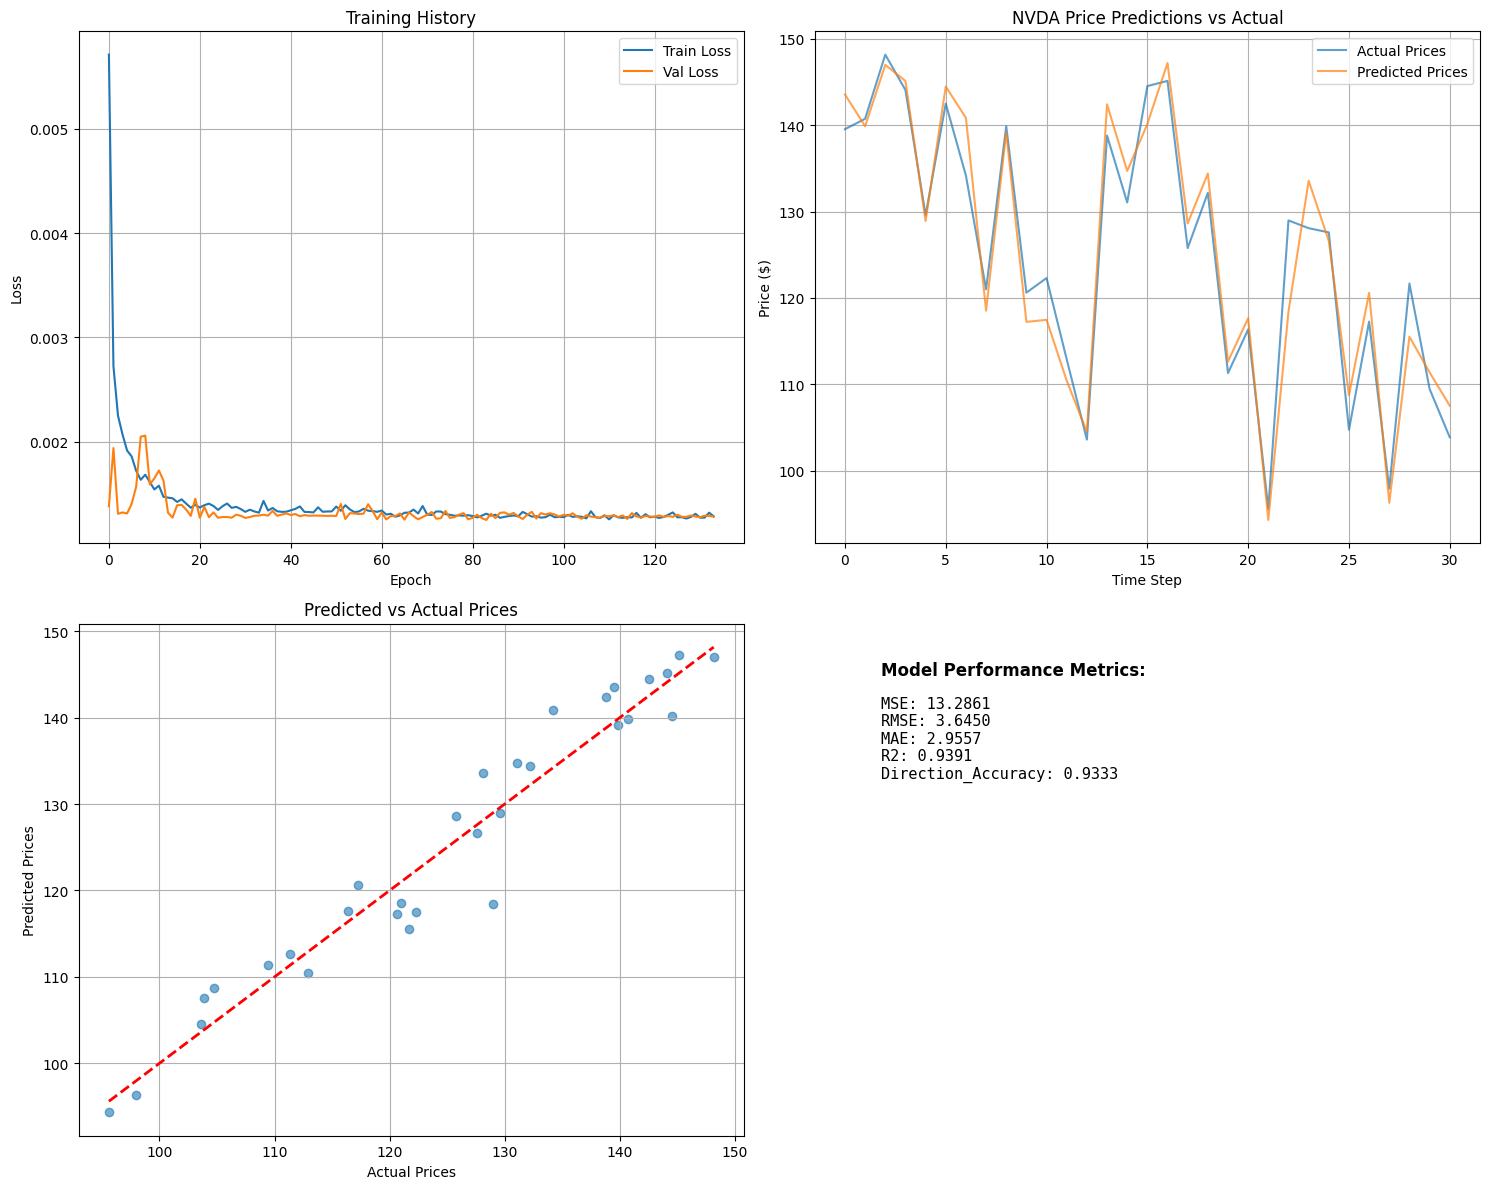

In [ ]:
# Visualize results
print("\nGenerating visualizations...")
plot_results(train_losses, val_losses, pred_prices, actual_prices, metrics)


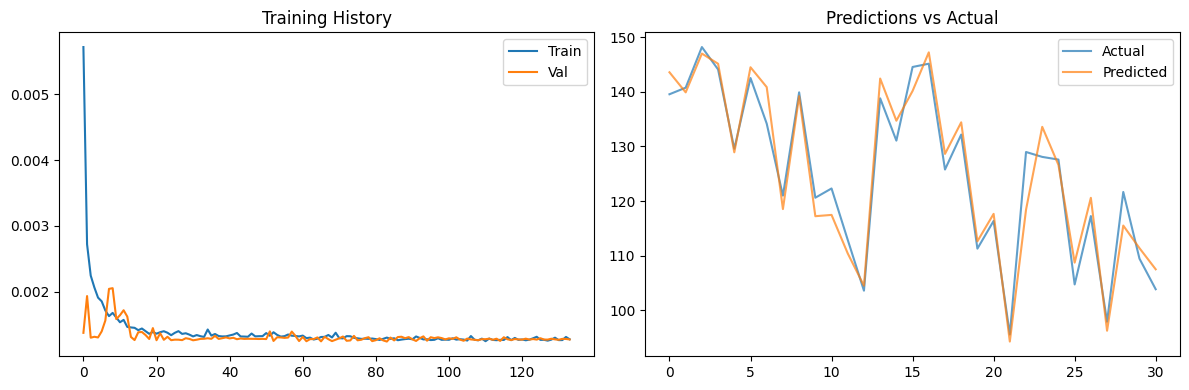


Top 10 features correlated with NVDA Adj_close:
Adj_close    1.000000
Close        1.000000
Low          0.999563
High         0.999441
Open         0.998856
Sma_20       0.992341
Sma_50       0.980859
Obv          0.935644
Sma_200      0.930746
Mdd_250d     0.754291
Name: Adj_close, dtype: float64


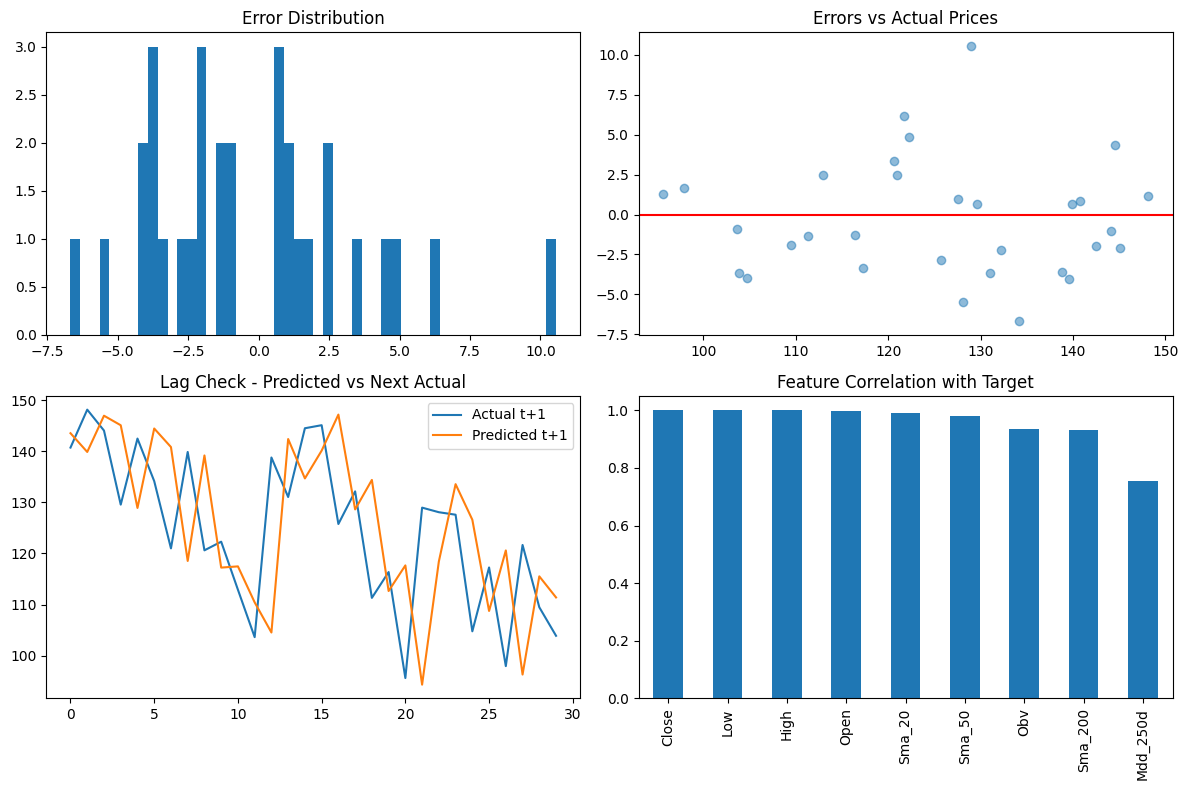


Error Stats:
Mean Error: $-0.27
Std Error: $3.63
Max Error: $10.56
Direction Accuracy: 93.3%


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
# 1. Training vs Validation Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Training History')
plt.legend()

# 2. Prediction Plot
plt.subplot(1, 2, 2)
plt.plot(actual_prices, label='Actual', alpha=0.7)
plt.plot(pred_prices, label='Predicted', alpha=0.7)
plt.title('Predictions vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Error Analysis
errors = actual_prices - pred_prices
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(errors, bins=50)
plt.title('Error Distribution')

plt.subplot(2, 2, 2)
plt.scatter(actual_prices, errors, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Errors vs Actual Prices')

# 4. Check if predictions are just lagged
plt.subplot(2, 2, 3)
plt.plot(actual_prices[1:], label='Actual t+1')
plt.plot(pred_prices[:-1], label='Predicted t+1')
plt.title('Lag Check - Predicted vs Next Actual')
plt.legend()

# 5. Feature correlation with target
nvda_df = stock_data_dict['NVDA']
feature_corrs = nvda_df[nvda_df.select_dtypes(include=[np.number]).columns].corr()['Adj_close'].sort_values(ascending=False)
print("\nTop 10 features correlated with NVDA Adj_close:")
print(feature_corrs.head(10))

plt.subplot(2, 2, 4)
feature_corrs.head(10)[1:].plot(kind='bar')  # Exclude Adj_close itself
plt.title('Feature Correlation with Target')
plt.tight_layout()
plt.show()

# 6. Print key metrics
print(f"\nError Stats:")
print(f"Mean Error: ${errors.mean():.2f}")
print(f"Std Error: ${errors.std():.2f}")
print(f"Max Error: ${errors.max():.2f}")
print(f"Direction Accuracy: {metrics['Direction_Accuracy']:.1%}")

# 7. Check if it's just predicting the previous value
prev_price_accuracy = np.mean(np.diff(actual_prices) > 0 == np.diff(pred_prices) > 0)
print(f"Would simply predicting 'no change' give: {prev_price_accuracy:.1%} accuracy")

*9-b Stock correlation matrix *

In [ ]:
def plot_correlation_analysis(dataset, sample_date_idx=100):
    """Plot correlation analysis between stocks"""
    correlation_matrix = dataset._calculate_correlations(sample_date_idx)
    stocks = list(dataset.stock_data_dict.keys())

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix,
                xticklabels=stocks,
                yticklabels=stocks,
                cmap='coolwarm',
                center=0,
                annot=True,
                fmt='.2f')
    plt.title('Stock Correlation Matrix')
    plt.tight_layout()
    plt.show()


 Generating correlations...


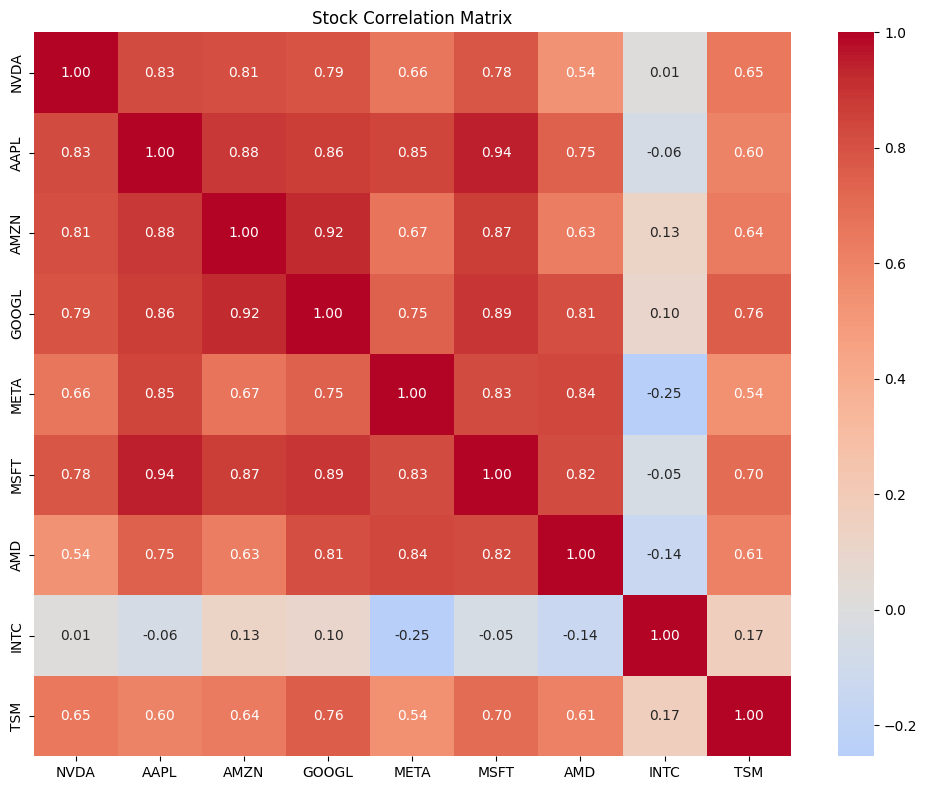

In [ ]:
print("\n Generating correlations...")
plot_correlation_analysis(dataset)

*9-c Analyzing feature importance*

In [ ]:
def analyze_feature_importance(model, dataset, test_loader, top_k=10):
    """Analyze which features are most important for predictions"""
    model.eval()
    feature_gradients = {feature: 0 for feature in dataset.feature_columns}

    for batch in test_loader:
        batch = batch.to(device)
        batch.x.requires_grad = True

        output = model(batch)
        # Compute gradients with respect to input features
        gradient = torch.autograd.grad(output, batch.x, grad_outputs=torch.ones_like(output))[0]

        # Average gradients across all nodes and samples
        mean_gradients = gradient.abs().mean(dim=0).cpu().numpy()

        for i, feature in enumerate(dataset.feature_columns):
            feature_gradients[feature] += mean_gradients[i]

    # Normalize and sort
    total_grad = sum(feature_gradients.values())
    feature_importance = {k: v/total_grad for k, v in feature_gradients.items()}
    sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

    # Plot top features
    top_features = sorted_importance[:top_k]
    features, importance = zip(*top_features)

    plt.figure(figsize=(12, 6))
    plt.barh(features, importance)
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_k} Most Important Features for NVDA Prediction')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return sorted_importance



Analyzing feature importance...


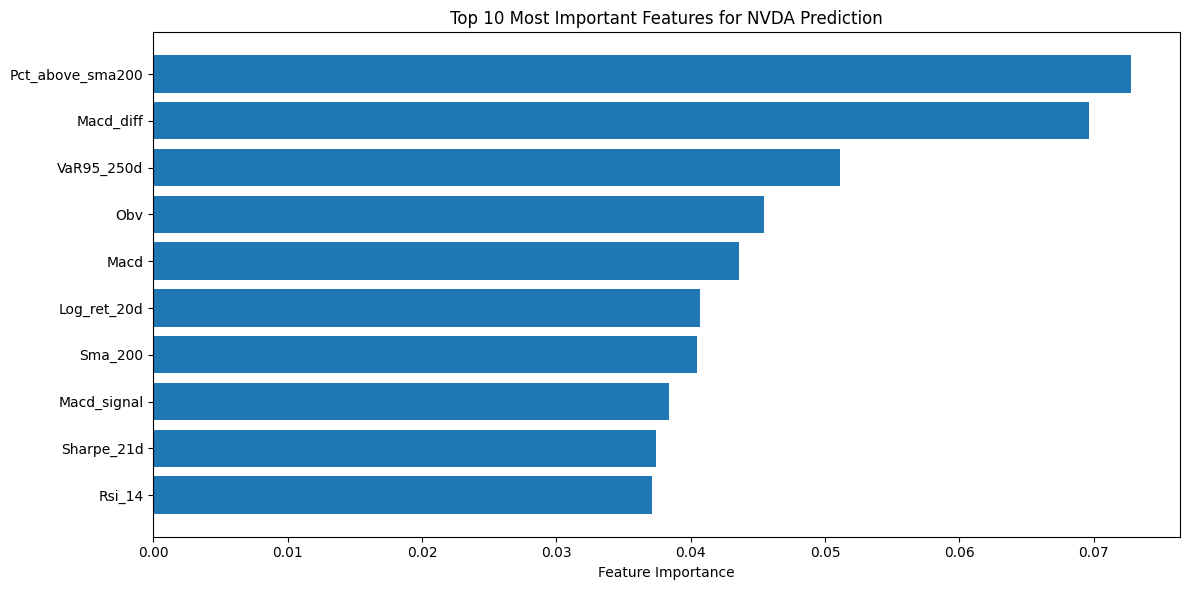

Saved feature importance to '/kaggle/working/feature_importance.csv'


In [ ]:
# Feature importance analysis (simplified)
print("\nAnalyzing feature importance...")

# Replace the current feature importance section with:
feature_importance = analyze_feature_importance(final_model, dataset, test_loader)
feature_importance_df = pd.DataFrame(feature_importance, columns=['Feature', 'Importance'])
feature_importance_df.to_csv('/kaggle/working/feature_importance.csv', index=False)
print("Saved feature importance to '/kaggle/working/feature_importance.csv'")

*9-d Plotting error timeline*

In [ ]:
def plot_error_timeline(predictions_df):
    """Plot prediction errors over time"""
    plt.figure(figsize=(15, 5))
    plt.plot(predictions_df['Date'], predictions_df['Error'], alpha=0.7, linewidth=1)
    plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')
    plt.title('Prediction Errors Over Time')
    plt.xlabel('Date')
    plt.ylabel('Prediction Error ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Generating additional insights...
📈 Plotting error timeline...


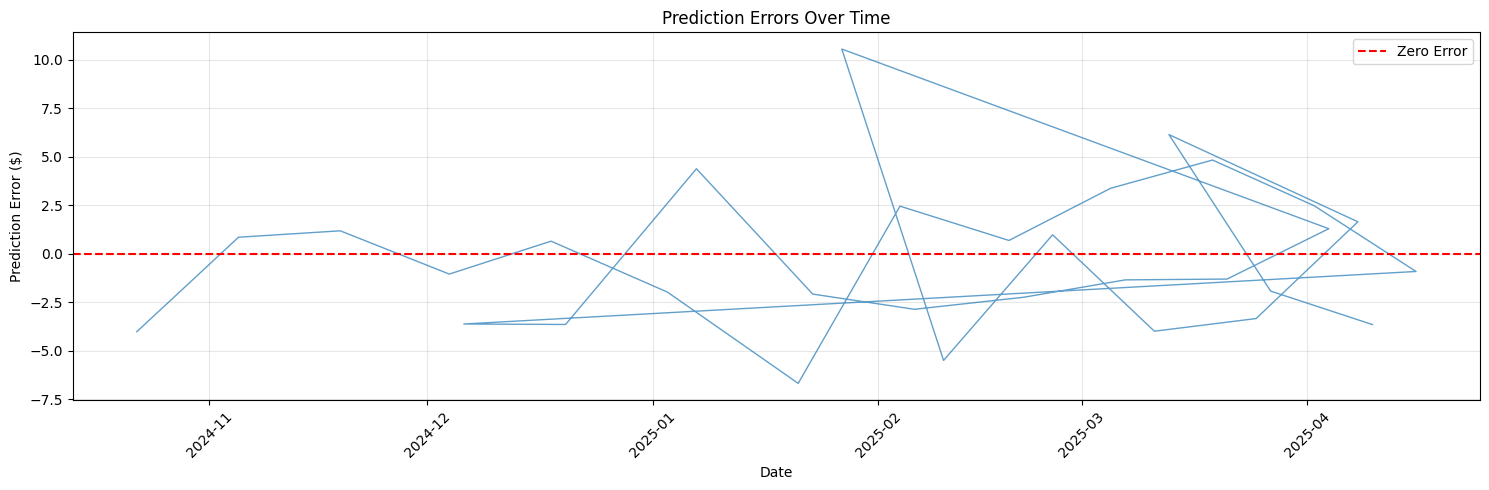

In [ ]:
# Add this right after your current visualization calls:

print("\nGenerating additional insights...")

# 1. Plot error timeline
print("📈 Plotting error timeline...")
plot_error_timeline(predictions_df)

*9-e Plotting graph relationships between stocks*

In [ ]:
def plot_graph_structure(dataset, sample_graph_idx=0):
    """Visualize the actual graph structure with nodes and edges"""
    try:
        import networkx as nx
    except ImportError:
        print("Installing networkx...")
        import subprocess
        subprocess.check_call(["pip", "install", "networkx"])
        import networkx as nx

    # Get a sample graph from your dataset
    sample_graph = dataset.graph_data_list[sample_graph_idx]
    stocks = list(dataset.stock_data_dict.keys())

    # Create NetworkX graph
    G = nx.Graph()

    # Add nodes (stocks)
    for i, stock in enumerate(stocks):
        G.add_node(stock)

    # Add edges from the graph data
    edge_index = sample_graph.edge_index.cpu().numpy()
    edge_weights = sample_graph.edge_attr.cpu().numpy()

    # Convert edge indices to stock names and add to graph
    for edge_idx in range(edge_index.shape[1]):
        source_idx = edge_index[0, edge_idx]
        target_idx = edge_index[1, edge_idx]
        weight = edge_weights[edge_idx]

        source_stock = stocks[source_idx]
        target_stock = stocks[target_idx]

        G.add_edge(source_stock, target_stock, weight=weight)

    # Create the plot
    plt.figure(figsize=(14, 10))

    # Use spring layout for better visualization
    pos = nx.spring_layout(G, k=3, iterations=50)

    # Draw nodes
    node_colors = ['red' if stock == 'NVDA' else 'lightblue' for stock in stocks]
    node_sizes = [1200 if stock == 'NVDA' else 800 for stock in stocks]

    nx.draw_networkx_nodes(G, pos,
                          node_color=node_colors,
                          node_size=node_sizes,
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=2)

    # Draw edges with weights as line thickness
    edges = G.edges()
    weights = [G[u][v]['weight'] * 5 for u, v in edges]  # Scale for visibility

    nx.draw_networkx_edges(G, pos,
                          edgelist=edges,
                          width=weights,
                          alpha=0.6,
                          edge_color='gray')

    # Draw labels
    nx.draw_networkx_labels(G, pos,
                           font_size=9,
                           font_weight='bold',
                           font_family='sans-serif')

    # Add edge weight labels
    edge_labels = {(u, v): f'{G[u][v]["weight"]:.2f}' for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title('GAT Graph Structure: Stock Relationships\n'
              '🔴 NVDA (Target) | 🔵 Other Stocks | Line Thickness = Correlation Strength',
              fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')

    # Add legend
    plt.figtext(0.02, 0.02,
                f'Graph Sample #{sample_graph_idx}\n'
                f'Total Nodes: {G.number_of_nodes()}\n'
                f'Total Edges: {G.number_of_edges()}\n'
                f'NVDA Connections: {G.degree("NVDA")}',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7),
                fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print detailed connection info
    print(f"\nGRAPH ANALYSIS - Sample #{sample_graph_idx}:")
    print(f"   Total stocks (nodes): {len(stocks)}")
    print(f"   Total connections (edges): {G.number_of_edges()}")
    print(f"   NVDA connections: {G.degree('NVDA')}")
    print(f"   Average connections per stock: {sum(dict(G.degree()).values()) / len(stocks):.1f}")

    print(f"\nNVDA's direct connections:")
    for neighbor in G.neighbors('NVDA'):
        weight = G['NVDA'][neighbor]['weight']
        print(f"   └─ {neighbor}: correlation = {weight:.3f}")


Showing actual GAT graph structure...


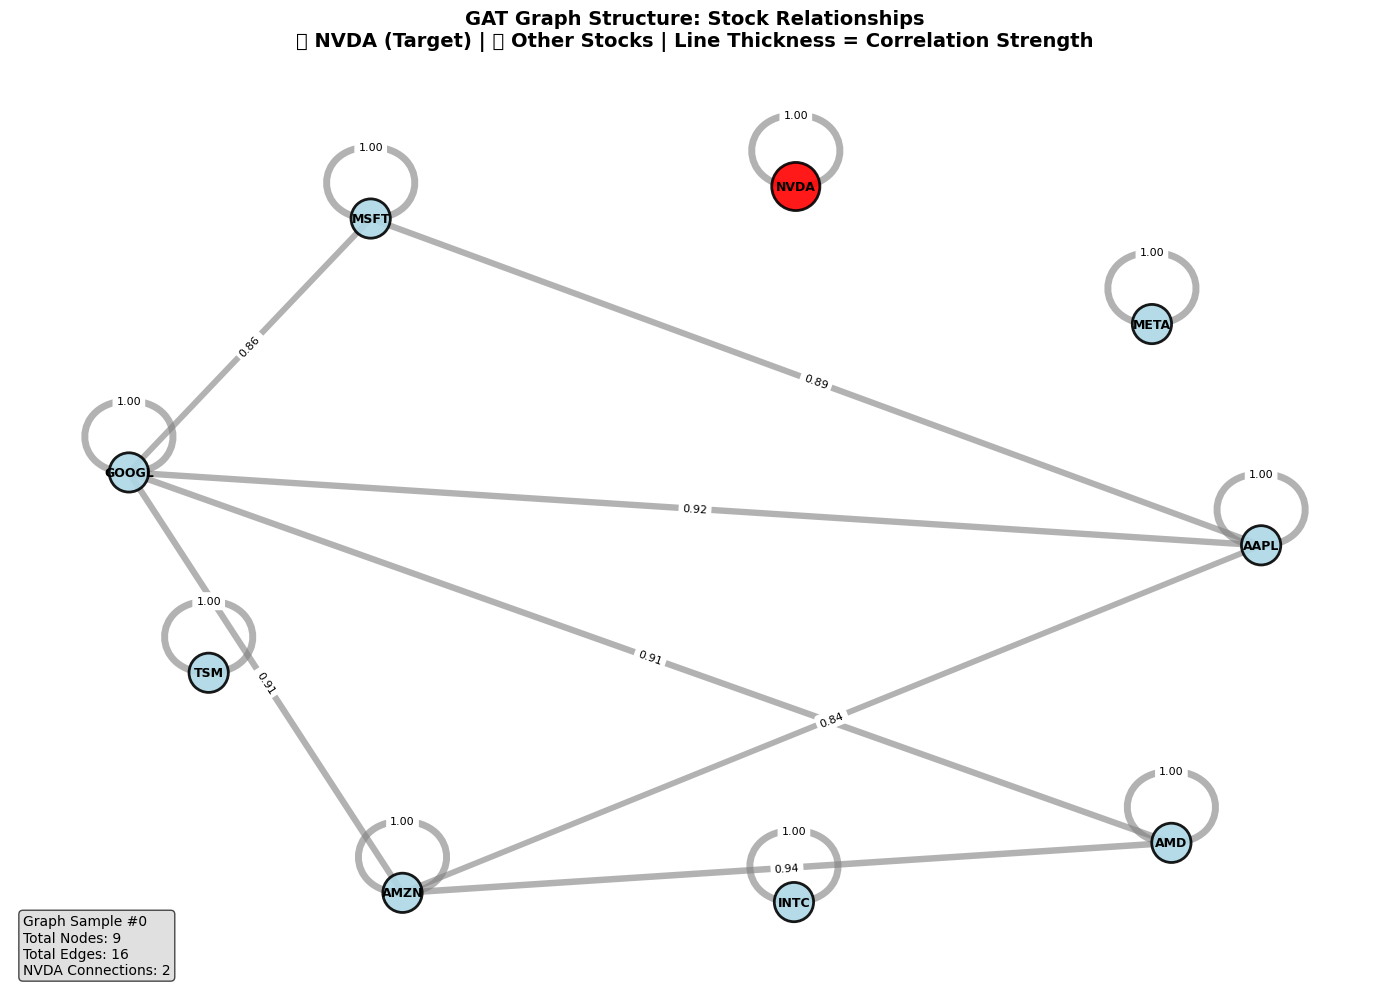


GRAPH ANALYSIS - Sample #0:
   Total stocks (nodes): 9
   Total connections (edges): 16
   NVDA connections: 2
   Average connections per stock: 3.6

NVDA's direct connections:
   └─ NVDA: correlation = 1.000


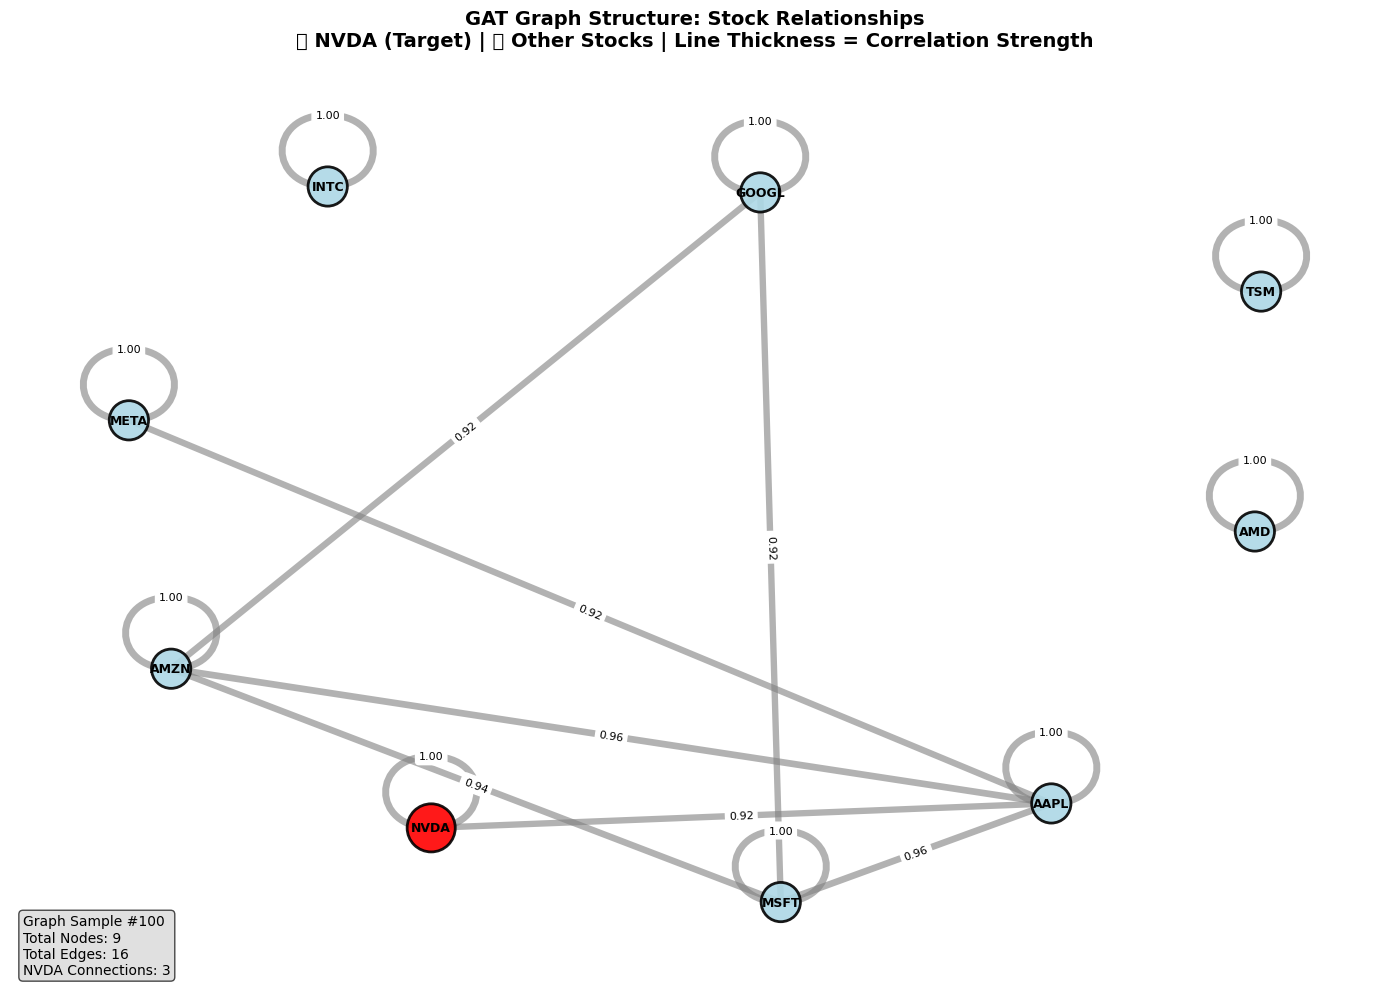


GRAPH ANALYSIS - Sample #100:
   Total stocks (nodes): 9
   Total connections (edges): 16
   NVDA connections: 3
   Average connections per stock: 3.6

NVDA's direct connections:
   └─ NVDA: correlation = 1.000
   └─ AAPL: correlation = 0.915


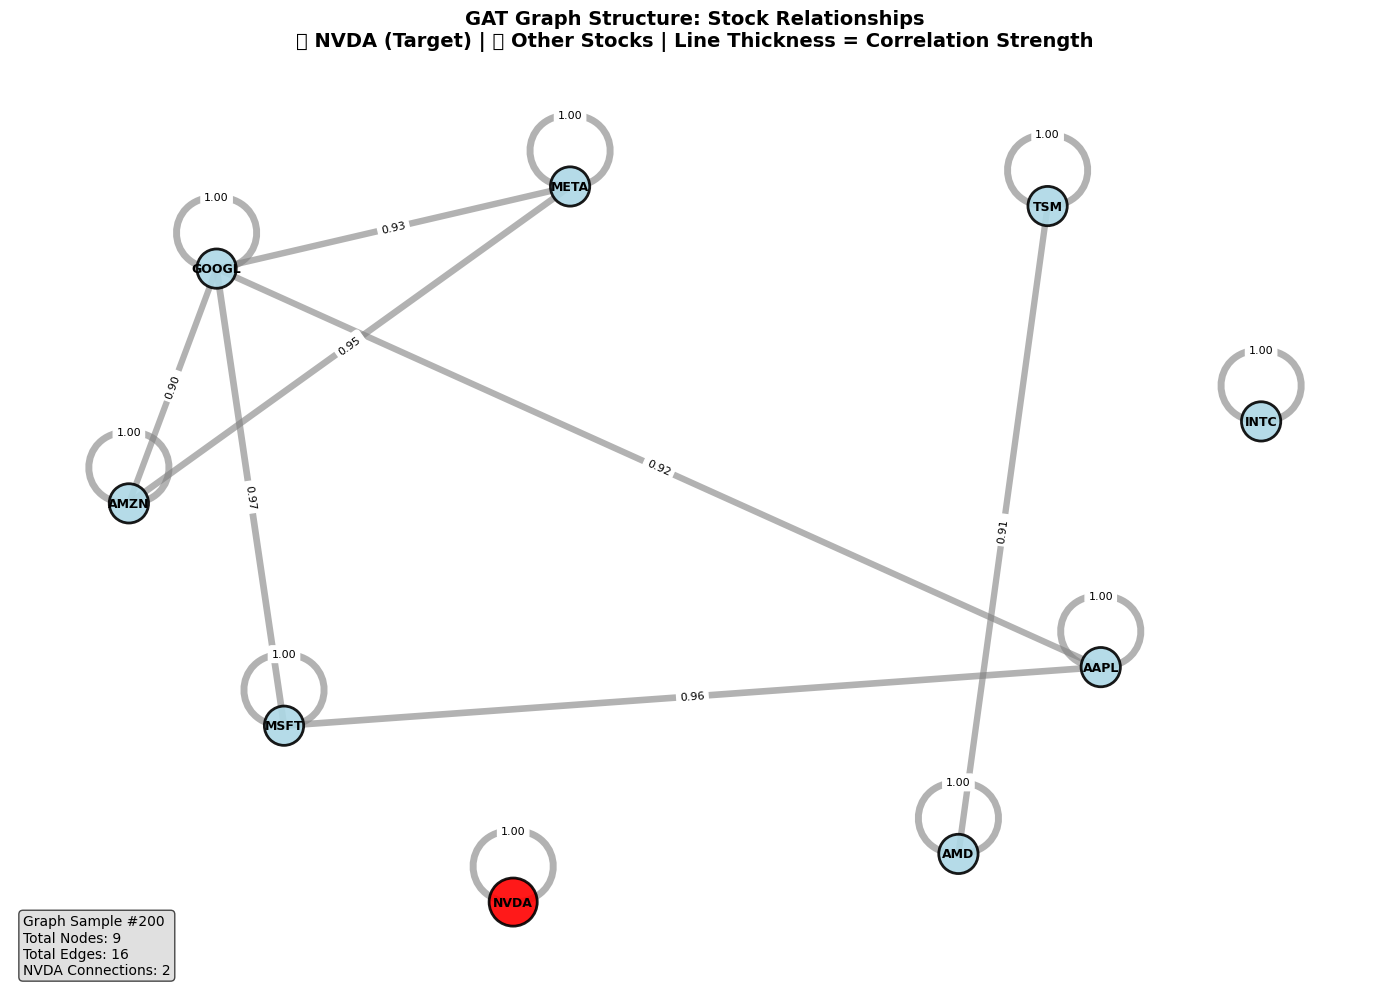


GRAPH ANALYSIS - Sample #200:
   Total stocks (nodes): 9
   Total connections (edges): 16
   NVDA connections: 2
   Average connections per stock: 3.6

NVDA's direct connections:
   └─ NVDA: correlation = 1.000


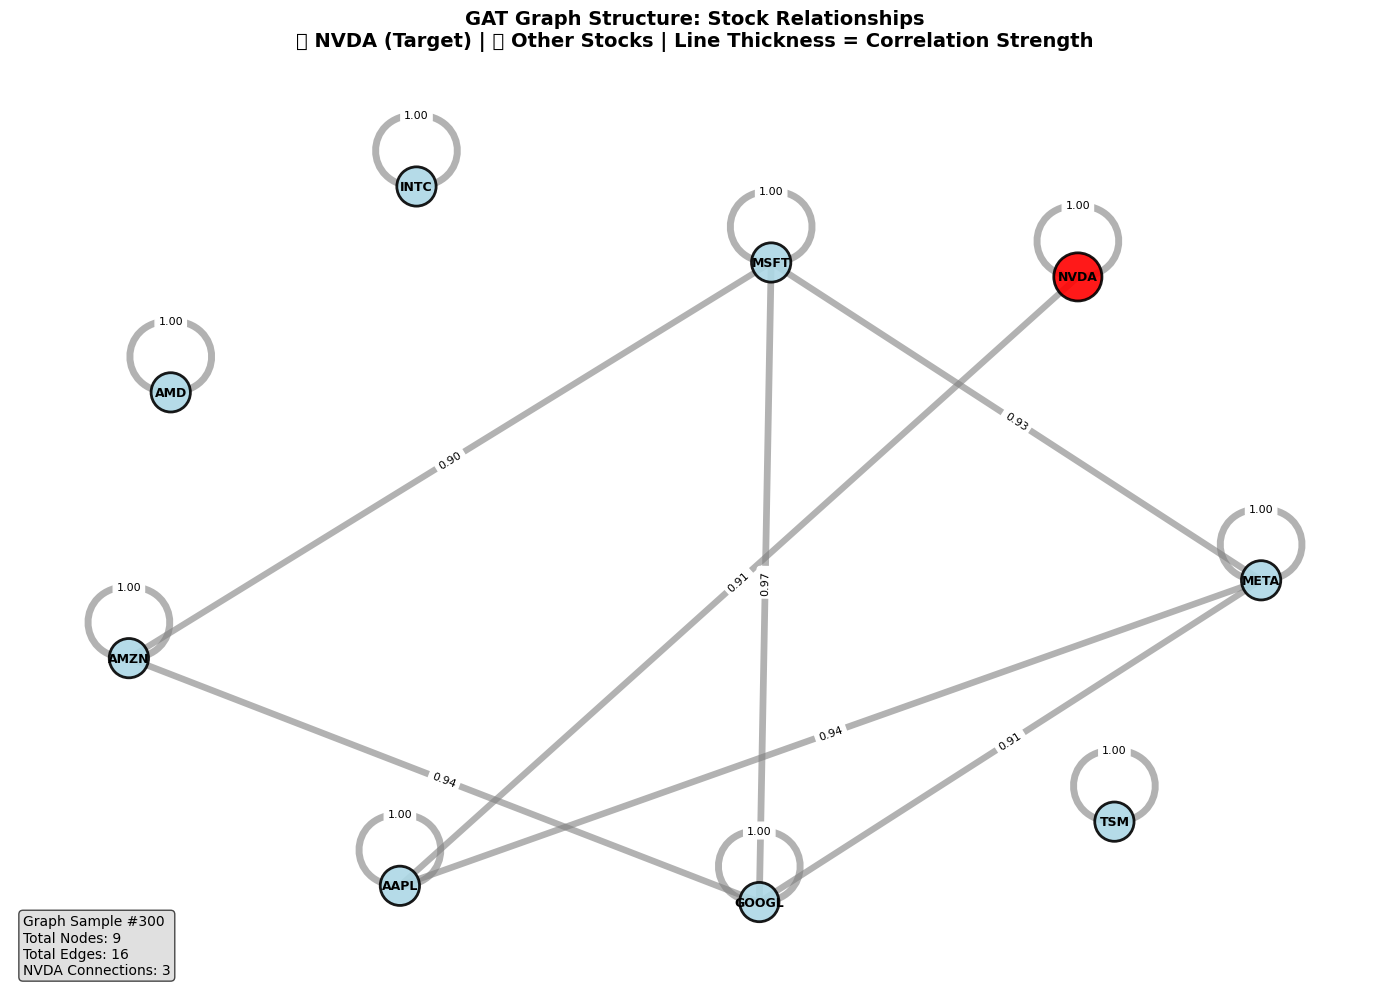


GRAPH ANALYSIS - Sample #300:
   Total stocks (nodes): 9
   Total connections (edges): 16
   NVDA connections: 3
   Average connections per stock: 3.6

NVDA's direct connections:
   └─ NVDA: correlation = 1.000
   └─ AAPL: correlation = 0.913


In [ ]:
print("\nShowing actual GAT graph structure...")

# Plot multiple graph samples to show dynamic relationships
sample_indices = [0, 100, 200, 300]  # Different time points
for sample_idx in sample_indices:
    if sample_idx < len(dataset.graph_data_list):
        plot_graph_structure(dataset, sample_graph_idx=sample_idx)
    else:
        print(f"Sample index {sample_idx} out of range")  # This line is correct


Showing actual GAT graph structure...


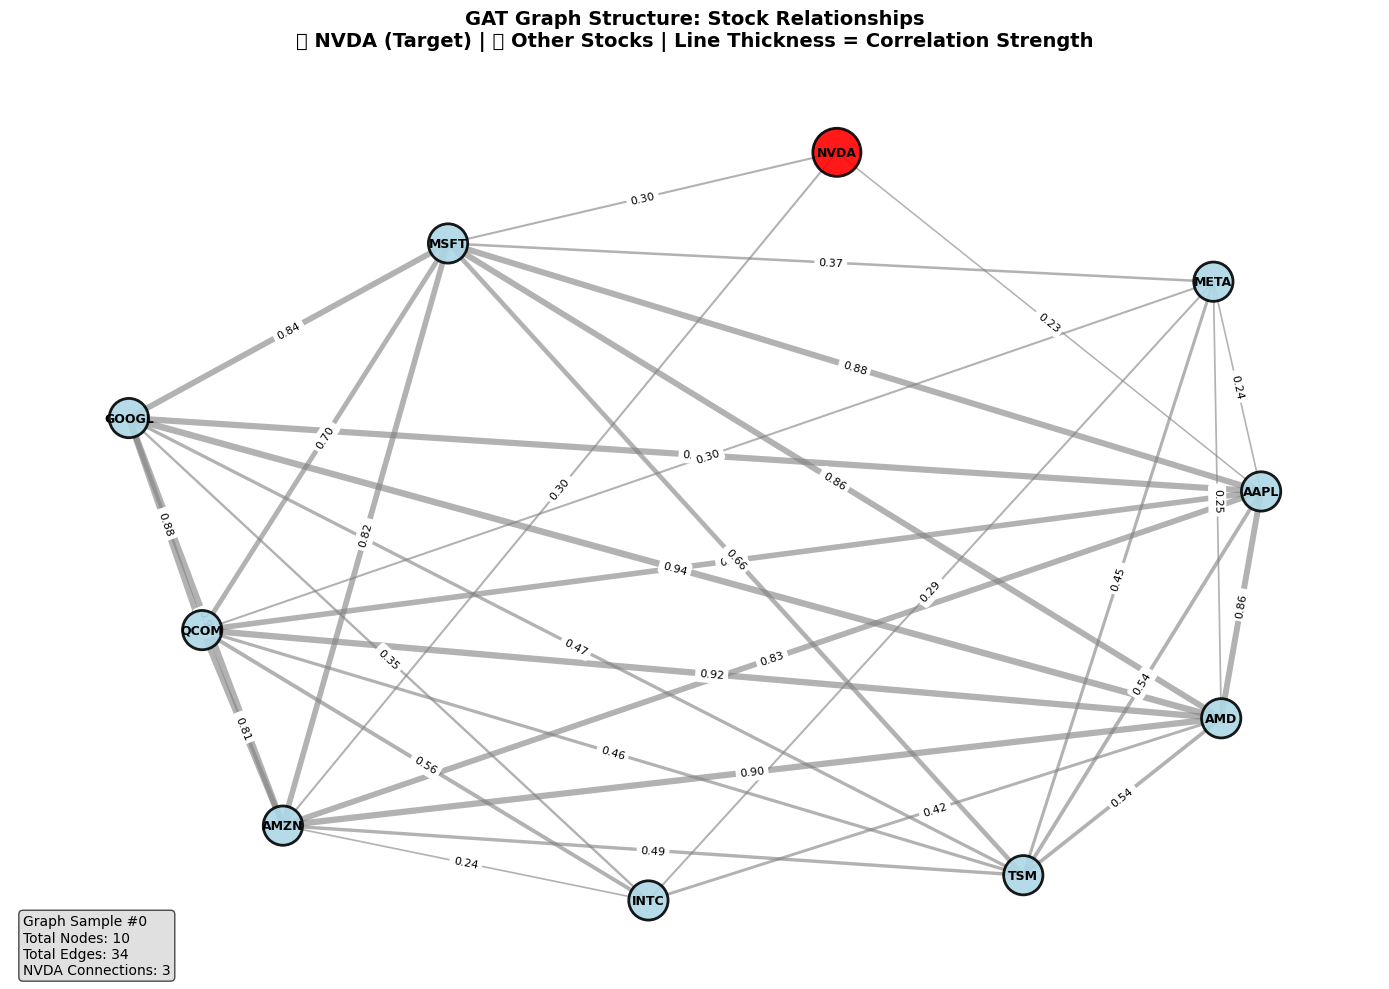


GRAPH ANALYSIS - Sample #0:
   Total stocks (nodes): 10
   Total connections (edges): 34
   NVDA connections: 3
   Average connections per stock: 6.8

NVDA's direct connections:
   └─ AAPL: correlation = 0.225
   └─ AMZN: correlation = 0.298
   └─ MSFT: correlation = 0.304


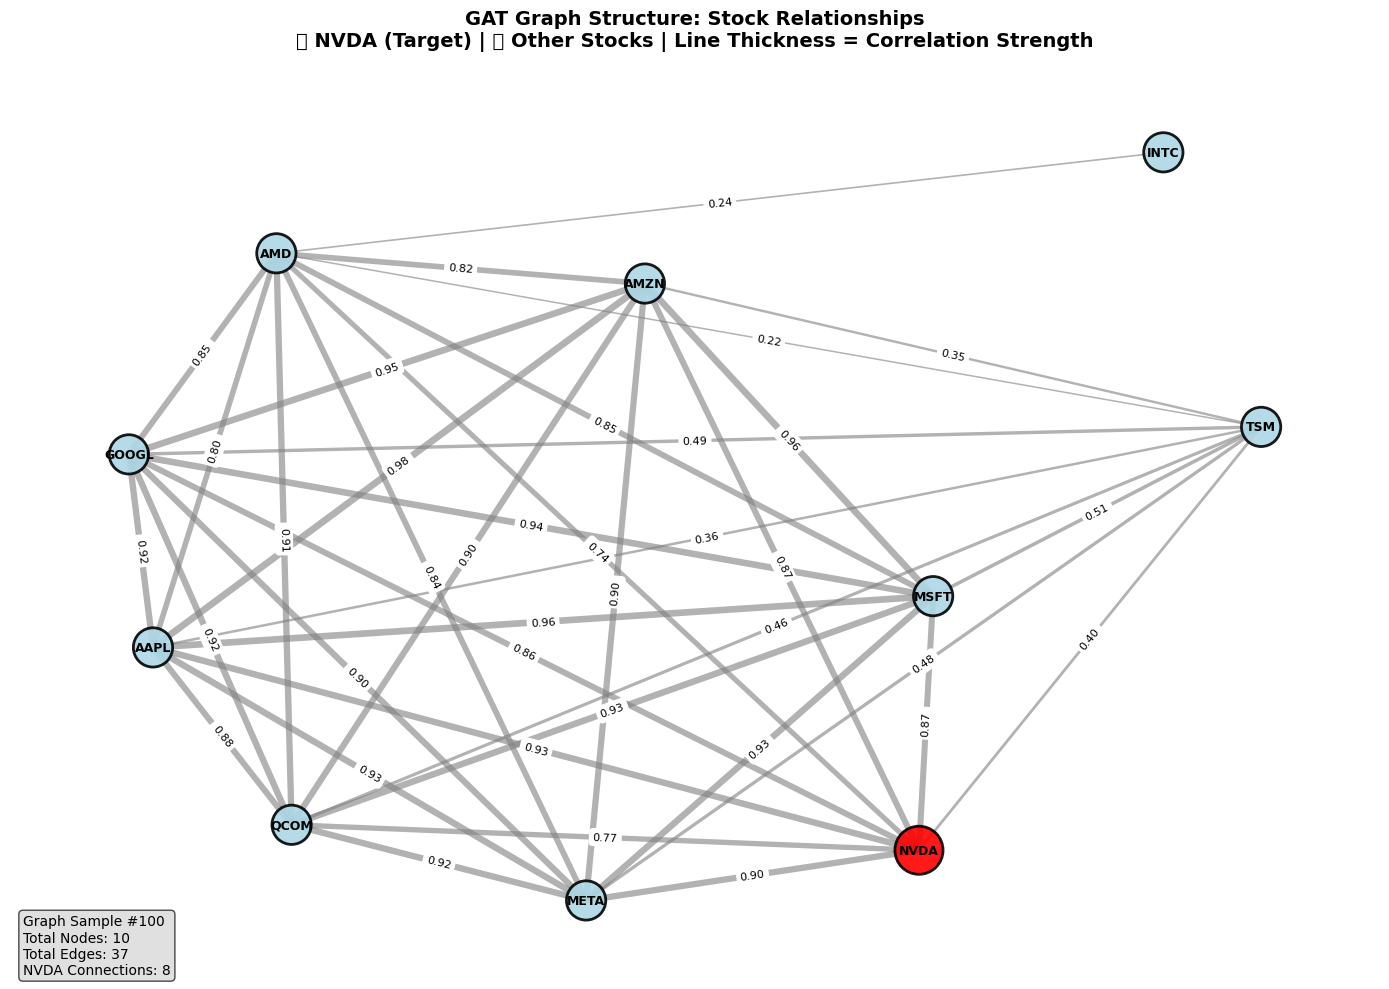


GRAPH ANALYSIS - Sample #100:
   Total stocks (nodes): 10
   Total connections (edges): 37
   NVDA connections: 8
   Average connections per stock: 7.4

NVDA's direct connections:
   └─ AAPL: correlation = 0.926
   └─ AMZN: correlation = 0.873
   └─ GOOGL: correlation = 0.864
   └─ META: correlation = 0.904
   └─ MSFT: correlation = 0.867
   └─ AMD: correlation = 0.742
   └─ QCOM: correlation = 0.770
   └─ TSM: correlation = 0.402


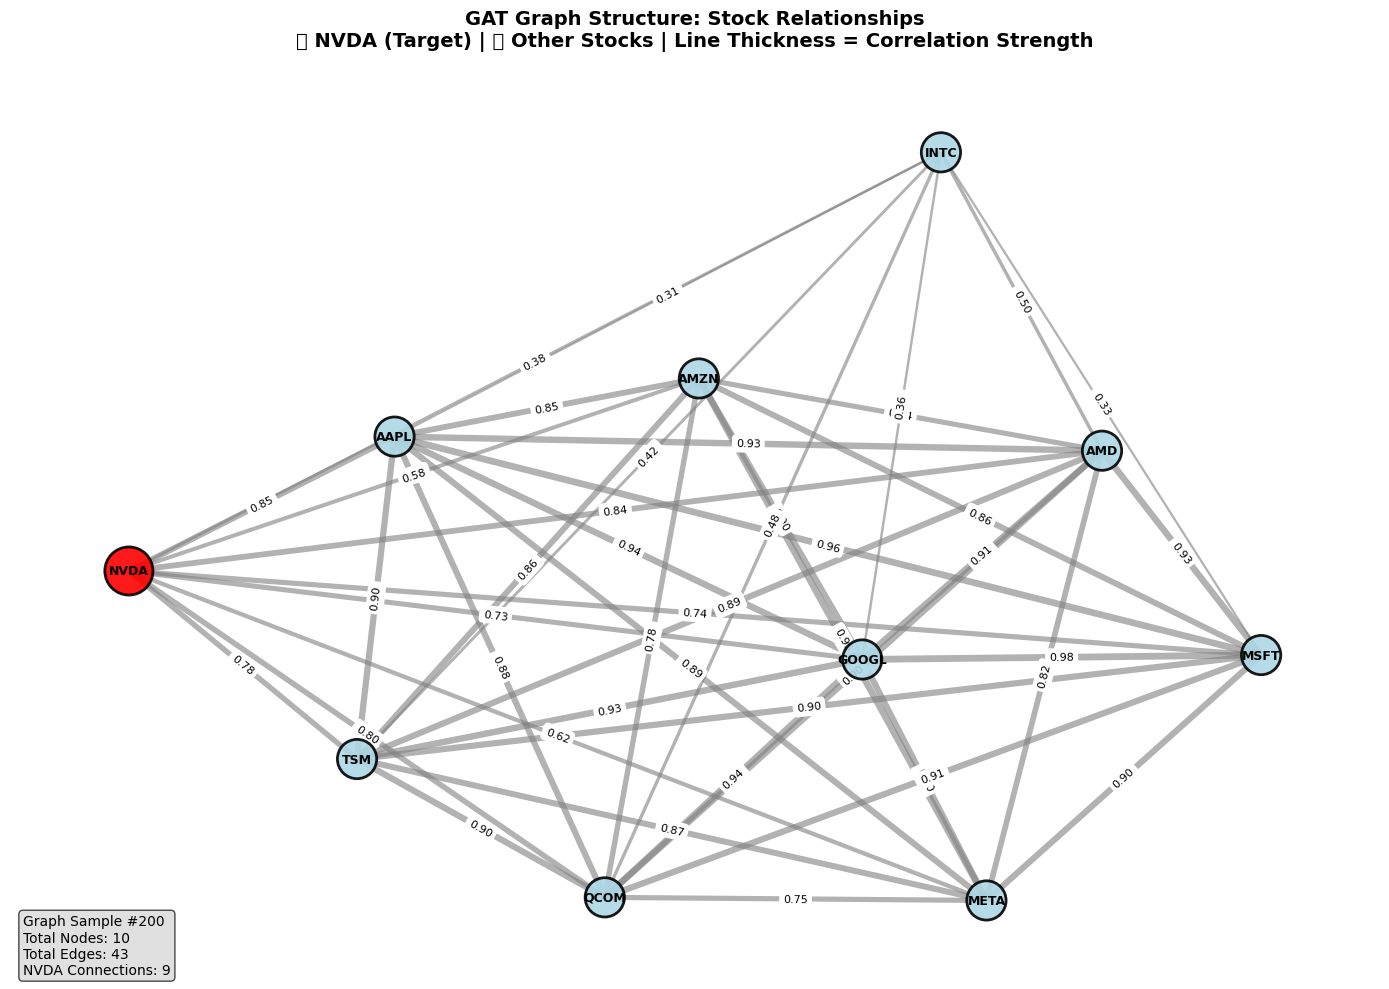


GRAPH ANALYSIS - Sample #200:
   Total stocks (nodes): 10
   Total connections (edges): 43
   NVDA connections: 9
   Average connections per stock: 8.6

NVDA's direct connections:
   └─ AAPL: correlation = 0.847
   └─ AMZN: correlation = 0.579
   └─ GOOGL: correlation = 0.731
   └─ META: correlation = 0.622
   └─ MSFT: correlation = 0.745
   └─ AMD: correlation = 0.836
   └─ INTC: correlation = 0.377
   └─ QCOM: correlation = 0.798
   └─ TSM: correlation = 0.780


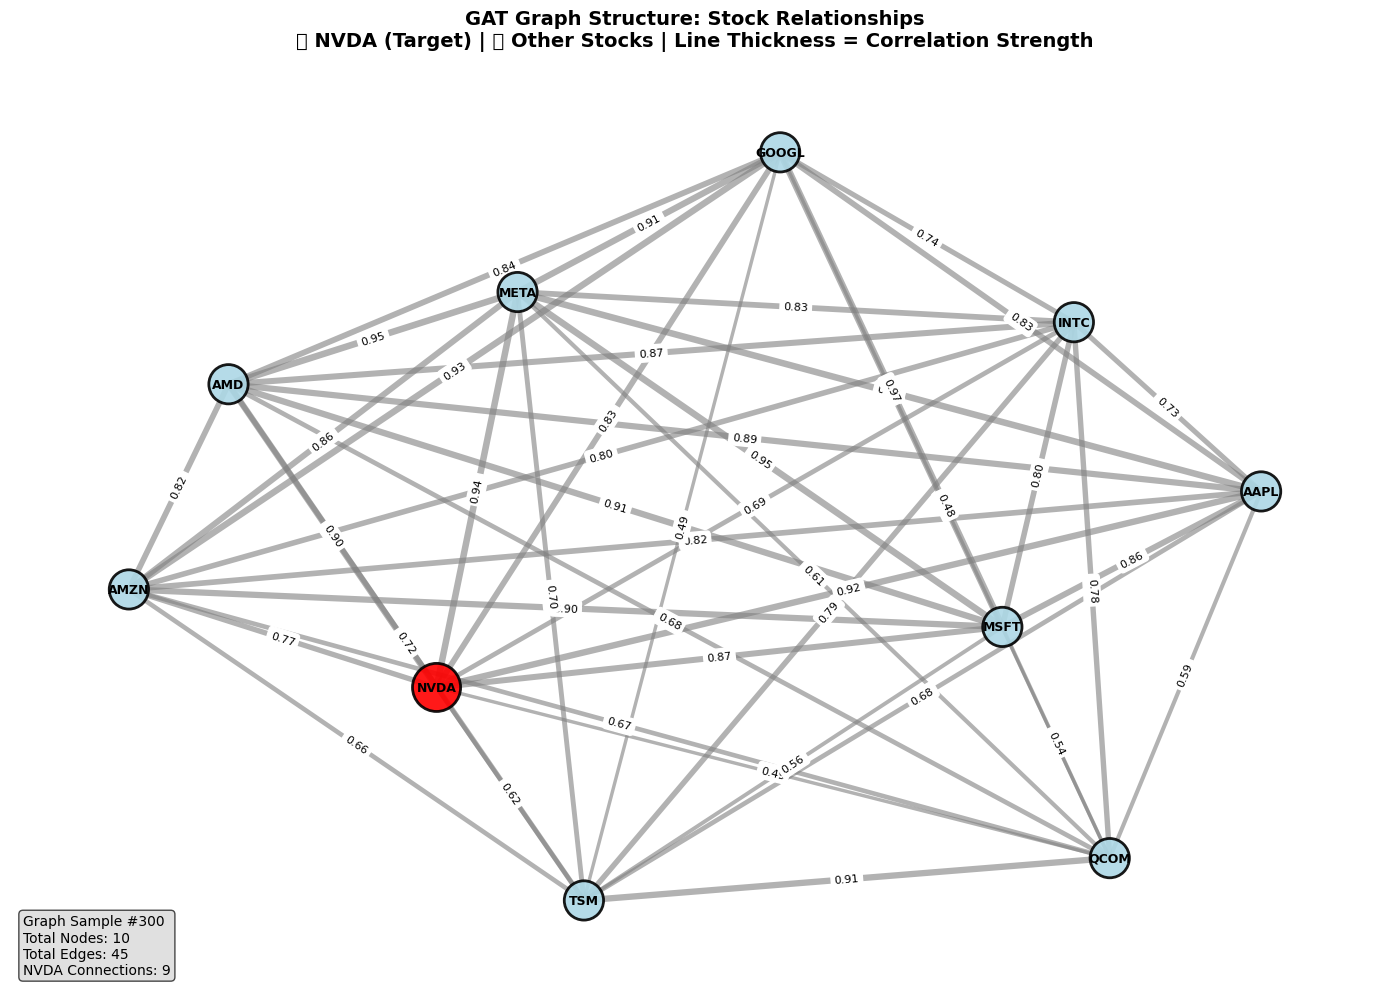


GRAPH ANALYSIS - Sample #300:
   Total stocks (nodes): 10
   Total connections (edges): 45
   NVDA connections: 9
   Average connections per stock: 9.0

NVDA's direct connections:
   └─ AAPL: correlation = 0.921
   └─ AMZN: correlation = 0.770
   └─ GOOGL: correlation = 0.832
   └─ META: correlation = 0.941
   └─ MSFT: correlation = 0.866
   └─ AMD: correlation = 0.901
   └─ INTC: correlation = 0.687
   └─ QCOM: correlation = 0.495
   └─ TSM: correlation = 0.618


In [ ]:
print("\nShowing actual GAT graph structure...")

# Plot multiple graph samples to show dynamic relationships
sample_indices = [0, 100, 200, 300]  # Different time points
for sample_idx in sample_indices:
    if sample_idx < len(dataset.graph_data_list):
        plot_graph_structure(dataset, sample_graph_idx=sample_idx)
    else:
        print(f"Sample index {sample_idx} out of range")